## Numbers Dataset

We have a dataset of handwritten digits from 0 to 9

We need some library to read the images, I've chosen the pillow library which comes with Anaconda, if you need to 

pip install Pillow

should install it for you

In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [2]:
##Printing Examples
def printexamples(X, y, examples_per_class = 10, number_of_classes = 10, mult = 1.0):
    pos = 0
    data = pd.DataFrame(y, columns=["yvalue"])
    for cls in range(number_of_classes):
        this_class = data[data["yvalue"] == cls]
        idxs = this_class.sample(examples_per_class).index
        for i, idx in enumerate(idxs):
            plt.subplot(examples_per_class, number_of_classes, i * number_of_classes + cls + 1)
            plt.imshow((X[idx]*mult).reshape(20,20).astype('uint8'), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title(str(cls))
    plt.show()

In [3]:
filelist = glob.glob("digits/digits/data/*/*.png")

X = np.array([np.array(Image.open(fname)).flatten() for fname in filelist])

In [4]:
X.shape

(5000, 400)

In [5]:
import os
y = np.array([int(os.path.basename(os.path.dirname(fname))) for fname in filelist])

In [6]:
y

array([0, 0, 0, ..., 9, 9, 9])

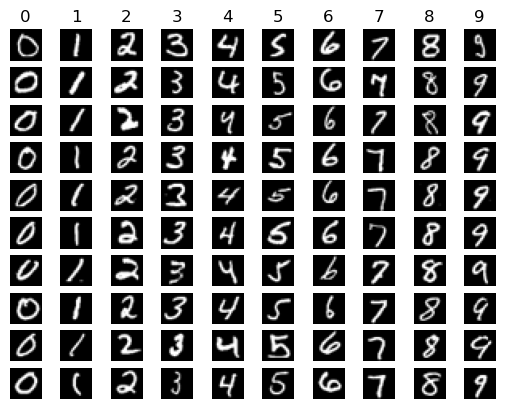

In [7]:
printexamples(X, y)

In [8]:
X = X/255.0

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [10]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, random_state = 1138, stratify = y, test_size = 0.2)

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, random_state = 1138, stratify = y_temp, test_size=0.25)

In [12]:
X_train.shape

(3000, 400)

In [13]:
X_valid.shape

(1000, 400)

In [14]:
X_test.shape

(1000, 400)

In [15]:
# Exercise 2
model = SVC(kernel = 'linear')

In [16]:
# Training data
model.fit(X_train, y_train)

SVC(kernel='linear')

In [17]:
# Validation
model.score(X_valid, y_valid)

0.926

In [18]:
model.score(X_train, y_train)

0.998

In [19]:
y_valid_pred = model.predict(X_valid)
confusion_m = confusion_matrix(y_valid, y_valid_pred)

print(confusion_m)

[[ 97   0   1   0   0   0   1   0   1   0]
 [  0 100   0   0   0   0   0   0   0   0]
 [  0   1  93   1   1   0   1   1   2   0]
 [  0   0   0  90   0   5   0   1   2   2]
 [  0   0   1   0  95   0   1   1   0   2]
 [  1   2   2   4   3  85   1   0   2   0]
 [  1   0   0   0   1   1  97   0   0   0]
 [  2   0   1   1   1   0   0  94   0   1]
 [  0   2   5   2   2   1   1   3  83   1]
 [  0   0   0   0   4   2   0   2   0  92]]


In [20]:
print(classification_report(y_valid, y_valid_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       100
           1       0.95      1.00      0.98       100
           2       0.90      0.93      0.92       100
           3       0.92      0.90      0.91       100
           4       0.89      0.95      0.92       100
           5       0.90      0.85      0.88       100
           6       0.95      0.97      0.96       100
           7       0.92      0.94      0.93       100
           8       0.92      0.83      0.87       100
           9       0.94      0.92      0.93       100

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [21]:
# Reset model, preventing influence from previous model/values
model = SVC(kernel = 'linear')

In [22]:
param_grid = {'C': [0.0001, 0.001, 0.01, 1, 10, 100, 1000, 10000]}

grid_model = GridSearchCV(model, param_grid=param_grid, verbose = 2)
# Verbose to see it below

In [23]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ...........................................C=0.0001; total time=   0.9s
[CV] END ...........................................C=0.0001; total time=   0.8s
[CV] END ...........................................C=0.0001; total time=   0.8s
[CV] END ...........................................C=0.0001; total time=   0.8s
[CV] END ...........................................C=0.0001; total time=   0.8s
[CV] END ............................................C=0.001; total time=   0.6s
[CV] END ............................................C=0.001; total time=   0.6s
[CV] END ............................................C=0.001; total time=   0.6s
[CV] END ............................................C=0.001; total time=   0.6s
[CV] END ............................................C=0.001; total time=   0.7s
[CV] END .............................................C=0.01; total time=   0.2s
[CV] END ........................................

GridSearchCV(estimator=SVC(kernel='linear'),
             param_grid={'C': [0.0001, 0.001, 0.01, 1, 10, 100, 1000, 10000]},
             verbose=2)

In [24]:
grid_model.best_params_

{'C': 1}

In [25]:
bestgrid = grid_model.best_estimator_
# If you want to store model, not necessary for exam

grid_model.score(X_valid, y_valid)

0.926

In [26]:
grid_model.score(X_train, y_train)

0.998

In [27]:
model_2 = RandomForestClassifier()

model_2.fit(X_train, y_train)

RandomForestClassifier()

In [28]:
model_2.score(X_train, y_train)

1.0

In [29]:
model_2.score(X_valid, y_valid)

0.942

In [30]:
param_grid = {'n_estimators': [20, 50, 100, 500, 1000], 'max_depth': [5, 10, 20, 50, 100]}
model = RandomForestClassifier(random_state=1138)
grid_model_2 = GridSearchCV(model, param_grid= param_grid, verbose=2)

In [31]:
grid_model_2.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .......................max_depth=5, n_estimators=20; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=20; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=20; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=20; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=20; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=50; total time=   0.1s
[CV] END .......................max_depth=5, n_estimators=50; total time=   0.1s
[CV] END .......................max_depth=5, n_estimators=50; total time=   0.1s
[CV] END .......................max_depth=5, n_estimators=50; total time=   0.1s
[CV] END .......................max_depth=5, n_estimators=50; total time=   0.1s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.3s
[CV] END ......................max_depth=5, n_e

GridSearchCV(estimator=RandomForestClassifier(random_state=1138),
             param_grid={'max_depth': [5, 10, 20, 50, 100],
                         'n_estimators': [20, 50, 100, 500, 1000]},
             verbose=2)

In [32]:
grid_model_2.best_score_

0.943

In [33]:
grid_model_2.best_params_

{'max_depth': 20, 'n_estimators': 500}

In [34]:
grid_model_2.score(X_train, y_train)

1.0

In [35]:
grid_model_2.score(X_valid, y_valid)

0.94

In [36]:
y_rf_pred = grid_model_2.predict(X_valid)
pd.DataFrame(confusion_matrix(y_valid, y_rf_pred), columns=range(10))

,0,1,2,3,4,5,6,7,8,9
0,97,0,0,0,0,1,1,0,1,0
1,0,99,1,0,0,0,0,0,0,0
2,1,0,94,1,1,0,0,0,2,1
3,0,1,3,89,0,4,0,1,0,2
4,0,0,1,0,93,0,3,0,0,3
5,1,1,0,4,1,90,3,0,0,0
6,1,0,0,0,0,0,99,0,0,0
7,2,1,0,0,1,0,0,94,0,2
8,0,3,1,1,0,0,3,0,92,0
9,0,0,0,0,4,0,0,1,2,93


In [37]:
print(classification_report(y_valid, y_rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       100
           1       0.94      0.99      0.97       100
           2       0.94      0.94      0.94       100
           3       0.94      0.89      0.91       100
           4       0.93      0.93      0.93       100
           5       0.95      0.90      0.92       100
           6       0.91      0.99      0.95       100
           7       0.98      0.94      0.96       100
           8       0.95      0.92      0.93       100
           9       0.92      0.93      0.93       100

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



In [38]:
# Section 4 - k-Nearest Neighbours
model_3 = KNeighborsClassifier(n_neighbors=5)
model_3.fit(X_train, y_train)

KNeighborsClassifier()

In [39]:
model_3.score(X_train, y_train)

0.9626666666666667

In [40]:
model_3.score(X_valid, y_valid)

0.946

In [41]:
param_grid_knn = {'n_neighbors': range(1, 30)}
model_knn = KNeighborsClassifier()
grid_knn = GridSearchCV(model_knn, param_grid=param_grid_knn, verbose=2)
grid_knn.fit(X_train, y_train)

Fitting 5 folds for each of 29 candidates, totalling 145 fits
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=3; total time=   0.0s
[CV] END ......................................

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 30)}, verbose=2)

In [42]:
grid_knn.best_score_

0.938

In [43]:
grid_knn.best_params_

{'n_neighbors': 4}

In [44]:
grid_knn.score(X_train, y_train)

0.9636666666666667

In [45]:
grid_knn.score(X_valid, y_valid)

0.943

In [46]:
# Section 5 - Logistic Regression
model_4 = LogisticRegression(max_iter=2000)
model_4.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [47]:
model_4.score(X_train, y_train)

0.9733333333333334

In [48]:
model_4.score(X_valid, y_valid)

0.905

In [49]:
Cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
param_grid_lr = {'C': Cs}
model_lr = LogisticRegression(max_iter=3000)
grid_logres = GridSearchCV(model_lr, param_grid=param_grid_lr, verbose=2)
grid_logres.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ...........................................C=0.0001; total time=   0.0s
[CV] END ...........................................C=0.0001; total time=   0.0s
[CV] END ...........................................C=0.0001; total time=   0.0s
[CV] END ...........................................C=0.0001; total time=   0.0s
[CV] END ...........................................C=0.0001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END ........................................

GridSearchCV(estimator=LogisticRegression(max_iter=3000),
             param_grid={'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             verbose=2)

In [50]:
grid_logres.best_score_

0.9103333333333333

In [51]:
grid_logres.best_params_

{'C': 1}

In [52]:
grid_logres.score(X_train, y_train)

0.9733333333333334

In [53]:
grid_logres.score(X_valid, y_valid)

0.905

In [54]:
# Section 6 - Model Selection
# Combine training and validation sets
X_trainvalid = np.vstack((X_train, X_valid))
y_trainvalid = np.hstack((y_train, y_valid))

In [55]:
# Retrain best model (kNN with best k from grid search) on combined train+validation set
best_model = KNeighborsClassifier(**grid_knn.best_params_)
best_model.fit(X_trainvalid, y_trainvalid)

KNeighborsClassifier(n_neighbors=4)

In [56]:
# Test set accuracy
best_model.score(X_test, y_test)

0.926

In [57]:
y_test_pred = best_model.predict(X_test)
pd.DataFrame(confusion_matrix(y_test, y_test_pred), columns=range(10))

,0,1,2,3,4,5,6,7,8,9
0,96,1,0,0,0,1,1,0,1,0
1,0,99,0,0,0,0,0,0,0,1
2,1,3,90,0,0,0,1,2,3,0
3,0,0,2,89,0,2,1,2,3,1
4,0,1,0,0,91,0,1,0,0,7
5,0,0,1,2,1,93,2,0,0,1
6,1,1,0,0,0,1,97,0,0,0
7,1,1,1,0,2,0,0,93,0,2
8,1,1,2,2,1,1,1,0,87,4
9,0,0,0,1,5,0,0,3,0,91


In [58]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       100
           1       0.93      0.99      0.96       100
           2       0.94      0.90      0.92       100
           3       0.95      0.89      0.92       100
           4       0.91      0.91      0.91       100
           5       0.95      0.93      0.94       100
           6       0.93      0.97      0.95       100
           7       0.93      0.93      0.93       100
           8       0.93      0.87      0.90       100
           9       0.85      0.91      0.88       100

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000

